# **Task 1**
# Dataset Understanding

uploading  dataset  from computer to current  notebook

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving netflix_titles.csv to netflix_titles.csv


importing several libraries pandas  for  data manuplation and analysis,numpy  for numerical values, matplotlib for     creatin visualization  and seaborn  for statistical analysis

In [ ]:
import pandas as pd
import numpy as nu
import matplotlib.pyplot as plt
import seaborn as sns

dataset is loaded into a pandas DataFrame using the `read_csv()` function    and the first 5 rows

In [ ]:
df=pd.read_csv('/content/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Number of rows and columns
df.shape


(8807, 12)

In [ ]:
#data types of  columns
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [ ]:
#categorical features
x= df.select_dtypes(include=['object', 'category']).columns
print("Categorical Features:",)
print(x.tolist())

#numerical features
y= df.select_dtypes(include=['number']).columns
print(y.tolist())
print("Numerical Features:")


Categorical Features:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'rating', 'duration', 'listed_in', 'description']
['release_year']
Numerical Features:


### Dataset Feature Description

The **Netflix Titles** dataset contains information about movies and TV shows available on Netflix. It provides details about each title, including its type, production information, release year, content rating, duration, genre, and a brief description. The dataset is useful for analyzing Netflix's content library, identifying content trends, and exploring patterns across different countries, genres, and years.

The key features in the dataset include:

* **show_id**: Unique identifier assigned to each Netflix title.
* **type**: Type of content (Movie or TV Show).
* **title**: Name of the movie or TV show.
* **director**: Director(s) of the content.
* **cast**: Main actors and actresses featured in the content.
* **country**: Country or countries where the content was produced.
* **date_added**: Date when the content was added to Netflix.
* **release_year**: Year the movie or TV show was originally released.
* **rating**: Content maturity rating (e.g., TV-MA, PG-13, TV-14, R).
* **duration**: Length of the movie (in minutes) or number of seasons for TV shows.
* **listed_in**: Genre(s) or category/categories assigned to the content.
* **description**: Short summary describing the storyline or content.


# **TASK 2**
# Data Cleaning

In [ ]:
# Identify columns with missing values  and Showing the number of missing values per column
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,0


In [ ]:
# Handle missing values appropriately.
df[df.select_dtypes(include='object').columns] = df.select_dtypes(include='object').fillna('Unknown')
df[df.select_dtypes(include='number').columns] = df.select_dtypes(include='number').fillna(0)

### Explanation of the Missing Value Handling Method

Missing values in **categorical (object)** columns were replaced with **"Unknown"** to preserve the records while clearly indicating that the original information was unavailable. This prevents unnecessary loss of data and allows the dataset to remain suitable for analysis.

Missing values in **numerical** columns were replaced with **0** because there were no appropriate values available for imputation, and using zero ensures that the dataset contains no missing numeric values. This approach was suitable since the Netflix dataset contains very few numerical columns and no missing values in `release_year`.


In [ ]:
#Duplicate Records
df.duplicated().sum()

np.int64(0)

In [ ]:
# Standardize only the identified inconsistencies

# Remove leading/trailing spaces
df['title'] = df['title'].str.strip()
df['date_added'] = df['date_added'].str.strip()

# Standardize text casing
df['title'] = df['title'].str.title()
df['rating'] = df['rating'].str.upper()

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Verify changes
print(df.dtypes)

AttributeError: Can only use .str accessor with string values!

In [ ]:
# data  validation

print("Missing show_id:", df['show_id'].eq('').sum())
print("Invalid type values:", df[~df['type'].isin(['Movie', 'TV Show'])]['type'].unique())
print("Negative release years:", (df['release_year'] < 0).sum())
print("Missing titles:", df['title'].eq('').sum())

Missing show_id: 0
Invalid type values: []
Negative release years: 0
Missing titles: 0


Invalid Values: The dataset was examined for invalid values in key columns. No missing show_id values, invalid type categories, negative release_year values, or missing title entries were found. Therefore, no corrective action was required for invalid values.





In [ ]:
# Check for incorrect formats
print(df.dtypes)

# Check if 'date_added' is a datetime column
if not pd.api.types.is_datetime64_any_dtype(df['date_added']):
    print("'date_added' has an incorrect format (stored as object).")
else:
    print("'date_added' format is correct.")

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object
'date_added' format is correct.


# **TASK 3**

# Exploratory Data Analysis (EDA)

In [ ]:
#  Generate Summary Statistics
df.describe()

,date_added,release_year
count,8797,8807.000000
mean,2019-05-17 05:59:08.436967168,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


# 1. Movies vs TV Shows Distribution

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


# 2. Content Added by Year

In [ ]:
df['date_added'].dt.year.value_counts().sort_index()

,count
date_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,429


# 3. Top 10 Content-Producing Countries

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


# 4. Most Common Content Ratings

In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


# 5. Most Common Genres/Categories

In [ ]:
genres = df['listed_in'].str.split(', ').explode()
genres.value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


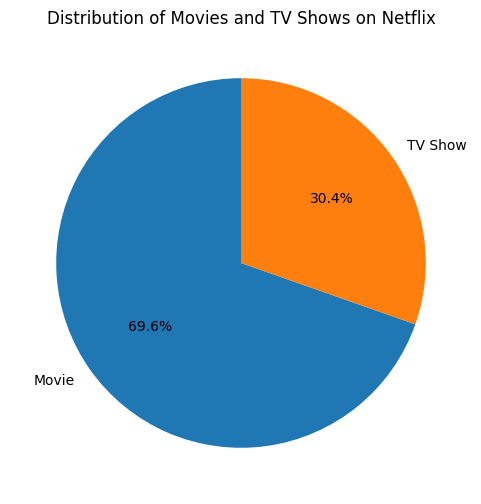

In [ ]:
# Movies vs TV Shows Distribution (Pie Chart)


plt.figure(figsize=(6,6))
plt.pie(
    content_counts,
    labels=content_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Movies and TV Shows on Netflix")
plt.show()

Finding: The pie chart shows that Movies constitute a larger share of Netflix's content library than TV Shows, indicating that Netflix primarily focuses on movie content while also offering a substantial collection of TV shows.

In [ ]:
import plotly.express as px

# Number of titles added each year
content_by_year = (
    df['date_added']
    .dt.year
    .value_counts()
    .sort_index()
    .reset_index()
)

content_by_year.columns = ['Year', 'Number of Titles']

fig = px.bar(
    content_by_year,
    x='Year',
    y='Number of Titles',
    color='Year',
    text='Number of Titles',
    title='Netflix Content Added by Year',
    color_discrete_sequence=px.colors.sequential.Turbo
)

fig.update_traces(textposition='outside')

fig.update_layout(
    title_x=0.5,
    template='plotly_white',
    xaxis_title='Year',
    yaxis_title='Number of Titles',
    yaxis_tickformat=',.0f',
    showlegend=False
)

fig.show()

Finding: The number of titles added to Netflix generally increased over the years, reaching its highest level around 2019, before declining slightly in the following years. This indicates that Netflix experienced significant growth in expanding its content library during the late 2010s.

In [ ]:
import plotly.express as px

# Top 10 Content-Producing Countries
top_countries = (
    df['country']
    .value_counts()
    .head(10)
    .reset_index()
)

top_countries.columns = ['Country', 'Number of Titles']

fig = px.bar(
    top_countries,
    x='Number of Titles',
    y='Country',
    orientation='h',
    color='Number of Titles',
    text='Number of Titles',
    title='Top 10 Content-Producing Countries on Netflix',
    color_continuous_scale='Turbo'
)

fig.update_traces(textposition='outside')

fig.update_layout(
    title_x=0.5,
    template='plotly_white',
    xaxis_title='Number of Titles',
    yaxis_title='Country',
    xaxis_tickformat=',.0f',
    coloraxis_showscale=False,
    yaxis={'categoryorder': 'total ascending'}
)

fig.show()

Finding: The United States contributes the highest number of titles to Netflix, followed by countries such as India and the United Kingdom. This indicates that Netflix's content library is heavily dominated by productions from a few leading countries.

In [ ]:
import plotly.express as px

# Content Ratings Distribution
rating_counts = (
    df['rating']
    .value_counts()
    .reset_index()
)

rating_counts.columns = ['Rating', 'Number of Titles']

fig = px.bar(
    rating_counts,
    x='Rating',
    y='Number of Titles',
    color='Rating',
    text='Number of Titles',
    title='Distribution of Netflix Content Ratings',
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_traces(textposition='outside')

fig.update_layout(
    title_x=0.5,
    template='plotly_white',
    xaxis_title='Content Rating',
    yaxis_title='Number of Titles',
    yaxis_tickformat=',.0f',
    showlegend=False
)

fig.show()

Finding: TV-MA is the most common content rating on Netflix, followed by TV-14. This indicates that a large proportion of Netflix's catalog is intended for mature and teenage audiences.

In [ ]:
import plotly.express as px

# Top 10 Netflix Genres
genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
    .reset_index()
)

genres.columns = ['Genre', 'Number of Titles']

fig = px.bar(
    genres,
    x='Number of Titles',
    y='Genre',
    orientation='h',
    color='Number of Titles',
    text='Number of Titles',
    title='Top 10 Netflix Genres',
    color_continuous_scale='Turbo'
)

fig.update_traces(textposition='outside')

fig.update_layout(
    title_x=0.5,
    template='plotly_white',
    xaxis_title='Number of Titles',
    yaxis_title='Genre',
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False
)

fig.show()